In [2]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.3 MB/s eta 0:00:00


In [4]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Use the function to set the seed
set_seed(42)


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv, global_mean_pool

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

dataset = KarateClub()
data = dataset[0]

num_train_nodes = int(0.8 * data.num_nodes)
data.train_mask = torch.zeros(data.num_nodes, dtype=bool)
data.train_mask[:num_train_nodes] = True
data.test_mask = ~data.train_mask

class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.out_channels = out_channels

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.bn2(self.conv2(x, edge_index))
        return x

class GNN_KNN_MLP(nn.Module):
    def __init__(self, gnn, mlp_hidden_dim, num_classes, k=2):
        super(GNN_KNN_MLP, self).__init__()
        self.gnn = gnn
        self.k = k
        self.pool = global_mean_pool
        self.mlp = nn.Sequential(
            nn.Linear(gnn.out_channels, mlp_hidden_dim),
            nn.ReLU(),
            nn.Linear(mlp_hidden_dim, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(mlp_hidden_dim, 1),
        )
        self.classifier = nn.Linear(gnn.out_channels, num_classes)

    def forward(self, x, edge_index, batch):
        embeddings = self.gnn(x, edge_index)
        distances = torch.cdist(embeddings, embeddings)
        knn_indices = torch.topk(-distances, self.k , dim=-1)[1][:, 1:]
        print('knn_indices: ', knn_indices)
        print('knn_indices.shape: ',knn_indices.shape)
        out_logits = torch.zeros((embeddings.size(0), self.classifier.out_features), device=x.device)

        complex_sets = []  # Store sets selected by MLP

        for i in range(embeddings.size(0)):
            knn_set = torch.cat((embeddings[knn_indices[i]], embeddings[i].unsqueeze(0)), dim=0)
            pooled_embedding = self.pool(knn_set, batch=None)
            mlp_test= self.mlp(pooled_embedding)
            print('mlp_test ', mlp_test)
            include_prob = torch.sigmoid(mlp_test).view(-1)
            inclusion_sample = (torch.rand_like(include_prob) < include_prob).float()
            straight_through_sample = inclusion_sample + (include_prob - include_prob.detach())

            selected_embedding = straight_through_sample * pooled_embedding + (1 - straight_through_sample) * embeddings[i]

            # print('include_prob: ', include_prob.grad)

            # print('selected_emb: ', selected_embedding.grad)

            # print('straigh_trough: ', straight_through_sample.grad)


            # Identify nodes in the current knn_set selected by MLP
            if inclusion_sample.item() == 1.0:
                complex_sets.append(tuple(knn_indices[i].tolist() + [i]))  # Save as tuple of node IDs

            out_logits[i] = self.classifier(selected_embedding)

        print(f"High-order sets selected by MLP: {complex_sets}")  # Shows node sets selected

        return F.log_softmax(out_logits, dim=-1)

num_classes = data.y.max().item() + 1
gnn = GNN(in_channels=dataset.num_node_features, hidden_channels=16, out_channels=8)
model = GNN_KNN_MLP(gnn, mlp_hidden_dim=16, num_classes=num_classes, k=3)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.batch)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

    # #Logging gradients
    # for name, param in model.named_parameters():
    #     if param.grad is not None:
    #         print(f"{name} gradient: {param.grad}")

    print(f"Training Loss: {loss.item()}")
    return loss.item()

def test():
    model.eval()
    correct = 0
    out = model(data.x, data.edge_index, data.batch)
    pred = out.argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_size = data.test_mask.sum().item()
    accuracy = correct / test_size if test_size > 0 else 0.0
    return accuracy

for epoch in range(1, 1000):
    train_loss = train()
    test_acc = test()
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Test Accuracy = {test_acc:.4f}\n")


A saída de streaming foi truncada nas últimas 5000 linhas.
mlp_test  tensor([[0.0145]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.0568]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0245]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.0035]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.1239]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.2122]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0919]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.1150]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.0003]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0377]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.0977]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0594]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0301]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[0.0620]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.3044]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.1139]], grad_fn=<AddmmBackward0>)
mlp_test  tensor([[-0.0536]], grad_fn=<AddmmBackward

KeyboardInterrupt: 

In [ ]:
for name, param in model.mlp.named_parameters():
    print(name, param.grad)

0.weight tensor([[-4.8575e-04, -3.4504e-04, -2.0423e-04,  4.3796e-04, -2.0944e-05,
         -2.2192e-04, -2.3137e-04, -5.1261e-04],
        [-3.6194e-04, -1.2135e-04,  5.1133e-05,  5.1961e-05, -1.2088e-04,
         -1.5990e-04,  1.9109e-04,  5.2277e-04],
        [-5.1699e-04, -8.0951e-04, -6.4206e-04,  8.2337e-04,  3.1611e-04,
          1.3078e-05,  1.1166e-04, -3.4942e-04],
        [-2.0491e-05,  7.9859e-05,  9.7344e-05,  1.8906e-05, -1.8183e-04,
         -3.5634e-04, -1.4530e-04, -2.6435e-04],
        [-2.4831e-05,  1.2288e-04,  1.3567e-04, -1.5094e-04, -5.1065e-05,
          1.5145e-04, -9.5406e-05,  8.9649e-05],
        [ 1.3634e-04,  5.7163e-04,  5.5874e-04, -7.2370e-04, -4.7631e-04,
         -3.3099e-05, -3.3935e-04,  4.7520e-05],
        [-1.6108e-04, -8.1648e-05, -4.1432e-05,  1.0045e-04,  7.8246e-05,
          1.2631e-04,  1.0710e-04,  1.0734e-04],
        [ 9.7371e-05,  2.8499e-04,  2.6876e-04, -2.9511e-04, -4.4975e-05,
          7.4632e-05, -2.2290e-04, -8.6277e-05],
       

#Including TNN


In [3]:
pip install toponetx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.4/704.4 kB 21.5 MB/s eta 0:00:00


In [4]:
pip install topomodelx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.9 MB/s eta 0:00:00


In [14]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv, global_mean_pool
from topomodelx.nn.simplicial.san import SAN
from torch_geometric.utils import coalesce



def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

dataset = KarateClub()
data = dataset[0]

num_train_nodes = int(0.8 * data.num_nodes)
data.train_mask = torch.zeros(data.num_nodes, dtype=bool)
data.train_mask[:num_train_nodes] = True
data.test_mask = ~data.train_mask

def remove_duplicated_edges(edge_index):
    arestas = set()
    for i in range(edge_index.size(1)):
        u = edge_index[0, i].item()
        v = edge_index[1, i].item()
        arestas.add((min(u, v), max(u, v)))  # Armazenar como um par ordenado
    return torch.tensor(list(arestas), dtype=torch.long).T

edge_index_undirected= remove_duplicated_edges(data.edge_index)

class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.out_channels = out_channels

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.bn2(self.conv2(x, edge_index))
        return x

class TNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.base_model = SAN(in_channels, hidden_channels, n_layers=2)
        self.linear = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, laplacian_up, laplacian_down):
        x = self.base_model(x, laplacian_up, laplacian_down)
        return torch.sigmoid(self.linear(x))



class GNN_KNN_MLP(nn.Module):
    def __init__(self, gnn, mlp_hidden_dim, tnn_hidden_dim, num_classes, k=2):
        super(GNN_KNN_MLP, self).__init__()
        self.gnn = gnn
        self.k = k
        self.pool = global_mean_pool

        self.mlp = nn.Sequential(
            nn.Linear(gnn.out_channels, mlp_hidden_dim),
            nn.ReLU(),
            nn.Linear(mlp_hidden_dim, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(mlp_hidden_dim, 1),
        )
        self.classifier = nn.Linear(gnn.out_channels, num_classes)
        self.tnn = TNN(in_channels=gnn.out_channels, hidden_channels=tnn_hidden_dim, out_channels=num_classes)

    def forward(self, x, edge_index, batch):
        embeddings = self.gnn(x, edge_index)
        distances = torch.cdist(embeddings, embeddings)
        knn_indices = torch.topk(-distances, self.k, dim=-1)[1]

        num_edges = edge_index_undirected.size(1)
        max_triangles = embeddings.size(0)
        incidence_matrix_temp = torch.zeros((num_edges, max_triangles), device=x.device)

        edge_map = {tuple(sorted(edge)): idx for idx, edge in enumerate(edge_index_undirected.T.tolist())}

        for i in range(embeddings.size(0)):
            knn_set = torch.cat((embeddings[knn_indices[i]], embeddings[i].unsqueeze(0)), dim=0)
            pooled_embedding = self.pool(knn_set, batch=None)

            include_prob = torch.sigmoid(self.mlp(pooled_embedding)).view(-1)
            inclusion_sample = (torch.rand_like(include_prob) < include_prob).float()
            straight_through_sample = inclusion_sample + (include_prob - include_prob.detach())

            selected_embedding = straight_through_sample * pooled_embedding + (1 - straight_through_sample) * embeddings[i]

            if inclusion_sample.item() == 1.0:
                complex_set = tuple(knn_indices[i].tolist())
                node_indices = sorted(complex_set)
                edges_in_triangle = [
                    (node_indices[0], node_indices[1]),
                    (node_indices[0], node_indices[2]),
                    (node_indices[1], node_indices[2]),
                ]

                # Populate incidence matrix with differentiable `straight_through_sample`
                for edge in edges_in_triangle:
                    edge_idx = edge_map.get(tuple(sorted(edge)))
                    if edge_idx is not None:
                        incidence_matrix_temp[edge_idx, i] = straight_through_sample

        incidence_matrix = incidence_matrix_temp.clone().requires_grad_()

        node_edge_matrix = torch.zeros((x.size(0), num_edges), device=x.device)
        for idx, edge in enumerate(edge_index_undirected.T):
            node_edge_matrix[edge[0], idx] = 1
            node_edge_matrix[edge[1], idx] = 1

        #print('shape edge index: ',edge_index_undirected.shape)

        #print('shape incidence edge-triangle: ', incidence_matrix.shape)

        #print('shape incidence node-edge: ', node_edge_matrix.shape)

        laplacian_up = incidence_matrix.T @ incidence_matrix
        laplacian_down = node_edge_matrix @ node_edge_matrix.T
        #print('ldown shape:', laplacian_down.shape)
        #print('lup shape: ', laplacian_up.shape)
        tnn_output = self.tnn(embeddings, laplacian_up=laplacian_up.to_sparse(), laplacian_down=laplacian_down.to_sparse())

        return F.log_softmax(tnn_output, dim=-1)

num_classes = data.y.max().item() + 1
gnn = GNN(in_channels=dataset.num_node_features, hidden_channels=16, out_channels=8)
model = GNN_KNN_MLP(gnn, mlp_hidden_dim=16, tnn_hidden_dim=16, num_classes=num_classes, k=3)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.batch)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    #  #Logging gradients
    # for name, param in model.named_parameters():
    #     if param.grad is not None:
    #         print(f"{name} gradient: {param.grad}")

    # print(f"Training Loss: {loss.item()}")
    return loss.item()

def test():
    model.eval()
    out = model(data.x, data.edge_index, data.batch)
    pred = out.argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
    test_accuracy = correct / data.test_mask.sum().item()
    train_correct = (pred[data.train_mask] == data.y[data.train_mask]).sum().item()
    train_accuracy = train_correct / data.train_mask.sum().item()
    return test_accuracy, train_accuracy

train_losses = []
test_accuracies = []
train_accuracies = []

for epoch in range(1, 500):
    train_loss = train()
    test_acc,train_acc = test()

     # Store the metrics
    train_losses.append(train_loss)
    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)

    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Test Accuracy = {test_acc:.4f}\n")


Epoch 1: Train Loss = 1.4160, Test Accuracy = 0.2857

Epoch 2: Train Loss = 1.3341, Test Accuracy = 0.2857

Epoch 3: Train Loss = 1.2572, Test Accuracy = 0.2857

Epoch 4: Train Loss = 1.2269, Test Accuracy = 0.2857

Epoch 5: Train Loss = 1.1952, Test Accuracy = 0.2857

Epoch 6: Train Loss = 1.1264, Test Accuracy = 0.1429

Epoch 7: Train Loss = 1.1082, Test Accuracy = 0.1429

Epoch 8: Train Loss = 1.0580, Test Accuracy = 0.1429

Epoch 9: Train Loss = 1.0087, Test Accuracy = 0.1429

Epoch 10: Train Loss = 0.9841, Test Accuracy = 0.2857

Epoch 11: Train Loss = 1.0289, Test Accuracy = 0.2857

Epoch 12: Train Loss = 1.0006, Test Accuracy = 0.2857

Epoch 13: Train Loss = 0.9799, Test Accuracy = 0.2857

Epoch 14: Train Loss = 0.9856, Test Accuracy = 0.1429

Epoch 15: Train Loss = 0.9167, Test Accuracy = 0.2857

Epoch 16: Train Loss = 0.8983, Test Accuracy = 0.2857

Epoch 17: Train Loss = 0.8518, Test Accuracy = 0.1429

Epoch 18: Train Loss = 0.8806, Test Accuracy = 0.5714

Epoch 19: Train Los

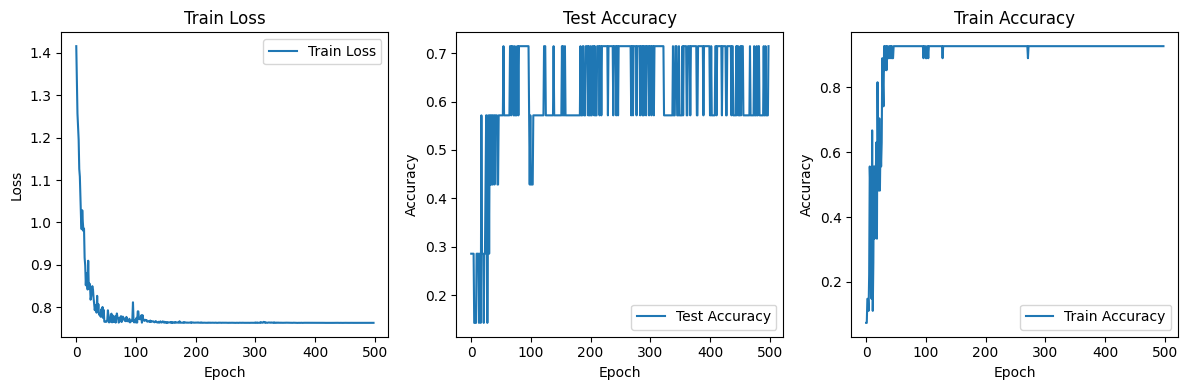

In [15]:
import matplotlib.pyplot as plt


# Plotting
plt.figure(figsize=(12, 4))

# Plot train loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train Loss')
plt.legend()

# Plot test accuracy
plt.subplot(1, 3, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()

# Plot train accuracy
plt.subplot(1, 3, 3)
plt.plot(train_accuracies, label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
import numpy as np
import toponetx as tnx
import torch
from topomodelx.nn.simplicial.san import SAN
from topomodelx.utils.sparse import from_sparse

# Step 1: Load the Karate Club dataset
karate_club_complex = tnx.datasets.karate_club(complex_type="simplicial")

# Step 2: Prepare Laplacians and node/edge features
laplacian_down = from_sparse(karate_club_complex.down_laplacian_matrix(rank=1))
laplacian_up = from_sparse(karate_club_complex.up_laplacian_matrix(rank=1))
incidence_0_1 = from_sparse(karate_club_complex.incidence_matrix(rank=1))

x_0 = torch.tensor(np.stack(list(karate_club_complex.get_simplex_attributes("node_feat").values())))
x_1 = torch.tensor(np.stack(list(karate_club_complex.get_simplex_attributes("edge_feat").values())))
x = x_1 + torch.sparse.mm(incidence_0_1.T, x_0)

# Step 3: Define the network
class TNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.base_model = SAN(in_channels, hidden_channels, n_layers=2)
        self.linear = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, laplacian_up, laplacian_down):
        x = self.base_model(x, laplacian_up, laplacian_down)
        return torch.sigmoid(self.linear(x))

# Step 4: Initialize the network and perform a forward pass
model = TNN(in_channels=x.shape[-1], hidden_channels=16, out_channels=2)
print('lup shape: ',laplacian_up.shape)
print('ldown shape: ', laplacian_down.shape)
y_hat_edge = model(x, laplacian_up=laplacian_up, laplacian_down=laplacian_down)

lup shape:  torch.Size([78, 78])
ldown shape:  torch.Size([78, 78])


In [ ]:
y_hat_

In [ ]:
def __get_boundary_matrix(self):
        boundary_matrix = torch.zeros((self.simplices_len, self.simplices_len))
        for j, simp in enumerate(self.simplices_list):
            if len(simp) == 1:
                continue
            else:
                d = len(simp)
                combos = list(itertools.combinations(simp, d-1))
                for c in combos:
                    boundary_matrix[self.simplices_indices[c], j] = 1
        return boundary_matrix

In [ ]:
data.edge_index[0:2,1]

tensor([0, 2])

In [ ]:
data.edge_index

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7, 12, 13,  0,  6, 10,  0,  6, 10, 16,  0,  4,  5, 16,  0,  1,
          2,  3,  0,  2, 30, 32, 33,  2, 33,  0,  4

In [ ]:
Tensor(num_edges, num_triangles)

In [ ]:
[e1][t1] -> [(edge_index[] ]

In [ ]:
from torch_geometric.utils import sort_edge_index

In [ ]:
sort_edge_index(data.edge_index)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7, 12, 13,  0,  6, 10,  0,  6, 10, 16,  0,  4,  5, 16,  0,  1,
          2,  3,  0,  2, 30, 32, 33,  2, 33,  0,  4